# Figure: Ablations — LM-pretraining impact (scratch vs finetuned; architecture & learning-rate search)

This figure compares the supervised Shorkie model under several training ablations to quantify the value of masked-LM pretraining. The key contrast is **Shorkie** (supervised tracks fine-tuned from the fungal masked-DNA language model) versus **Shorkie_Random_Init** (the same architecture trained from scratch with no LM pretraining). We also sweep learning rates and the pretraining corpus (R64 yeast vs. 80 strains vs. 1341 fungal genomes), and compare U-Net vs. CovNet capacity variants. Each variant is an 8-fold cross-validation ensemble; we read each fold's training log, take the best-epoch metric per fold, and summarize across folds.

**Reproduces:** the learning-rate / scratch-vs-finetuned bar comparison and the finetuning-corpus cross-validation curve comparison in the Shorkie ablation study.

**Upstream:** the per-fold `train/f{fold}c0/train.out` logs are produced by the fold-training runs under `scripts/02_train/shorkie_finetuned/` (westminster_train_folds.py, LM-finetuned) and `scripts/02_train/shorkie_scratch/` (architecture-search, learning-rate-search, and finetuning-dataset experiments). Those training jobs (GPU/SLURM) must complete first; this notebook only parses their text logs.

**Requires:** the `yeast_ml` conda env and `pip install -e .` from the repo root. No GPU needed (log parsing + plotting only). This notebook is **not** runnable from released data — it depends on unreleased training logs under `results.train_logs`.

**Source script:** ported from `scripts/04_analysis/shorkie_scratch/2_lr_search/3_compare_lr_variants_bar.py` (bar chart), with the corpus-curve panel adapted from `scripts/04_analysis/shorkie_scratch/3_finetuning_datasets/2_compare_cross_valid_curves_subplot_various_mlm.py` and the architecture variants from `scripts/04_analysis/shorkie_scratch/1_architecture_search/2_compare_variants_subplot.py`.

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from shorkie import config

In [2]:
# All ablation experiments live under the supervised training-log root.
# results.train_logs resolves to the 16bp supervised experiment directory; each
# variant is a subdirectory containing train/f{fold}c0/train.out for folds 0..7.
train_logs_root = config.path('results.train_logs')
model_arch = 'unet_small_bert_drop'   # the published Shorkie supervised head
num_folds = 8
print('train_logs_root:', train_logs_root)
assert os.path.isdir(train_logs_root), f'missing training-log root: {train_logs_root}'

train_logs_root: /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/seq_experiment/exp_histone__chip_exo__rna_seq_no_norm_5215_tracks/16bp


In [3]:
def parse_all_metrics(log_file, prefix='Epoch '):
    """Parse per-epoch (train_loss, train_r, train_r2, valid_loss, valid_r, valid_r2)
    from a baskerville/hound train.out log. Each epoch line looks like:
    'Epoch 1 - train_loss: 0.5 - train_r: 0.45 - train_r2: ... - valid_loss: ... - valid_r: ... - valid_r2: ...'
    """
    cols = {k: [] for k in ['train_loss', 'train_r', 'train_r2', 'valid_loss', 'valid_r', 'valid_r2']}
    if not os.path.exists(log_file):
        return cols
    with open(log_file) as f:
        for line in f:
            line = line.strip()
            if not line.startswith(prefix):
                continue
            parts = line.split(' - ')
            try:
                cols['train_loss'].append(float(parts[2].split(': ')[1]))
                cols['train_r'].append(float(parts[3].split(': ')[1]))
                cols['train_r2'].append(float(parts[4].split(': ')[1]))
                cols['valid_loss'].append(float(parts[5].split(': ')[1]))
                cols['valid_r'].append(float(parts[6].split(': ')[1]))
                cols['valid_r2'].append(float(parts[7].split(': ')[1]))
            except (IndexError, ValueError):
                continue
    return {k: np.array(v) for k, v in cols.items()}


def fold_log_paths(exp_dir):
    """Return the 8 per-fold train.out paths for an experiment directory."""
    return [os.path.join(exp_dir, 'train', f'f{i}c0', 'train.out') for i in range(num_folds)]


def _moving_average(x, window_size=11, trim_end=5):
    x_avg = np.zeros_like(x, dtype=float)
    for j in range(x.shape[0]):
        w = min(j, x.shape[0] - 1 - j, window_size // 2)
        x_avg[j] = np.mean(x[j - w:j + w + 1])
    return x_avg[:-trim_end] if 0 < trim_end < x.shape[0] else x_avg

In [4]:
# ------------------------------------------------------------------
# Build the variant -> per-fold-log-files map for the LR / scratch-vs-finetuned bar chart.
# ------------------------------------------------------------------
variants_dir = os.path.join(train_logs_root, f'supervised_{model_arch}_variants')

models_data = {}
# Shorkie_Random_Init: trained from scratch (no LM), the LR=0.0005 from-scratch run.
models_data['Shorkie_Random_Init'] = fold_log_paths(os.path.join(variants_dir, 'learning_rate_0.0005'))
# Shorkie: supervised head fine-tuned from the masked-LM checkpoint.
models_data['Shorkie'] = fold_log_paths(os.path.join(train_logs_root, f'self_supervised_{model_arch}'))
# Remaining from-scratch learning-rate sweep (exclude 0.0005, already the Random_Init bar).
for lr_dir in sorted(glob.glob(os.path.join(variants_dir, 'learning_rate_*'))):
    if os.path.basename(lr_dir) == 'learning_rate_0.0005':
        continue
    label = os.path.basename(lr_dir).replace('learning_rate_', 'LR=')
    models_data[label] = fold_log_paths(lr_dir)

for k, files in models_data.items():
    print(f'{k:24s} {sum(os.path.exists(p) for p in files)}/{num_folds} fold logs present')

Shorkie_Random_Init      8/8 fold logs present
Shorkie                  8/8 fold logs present
LR=0.0001                8/8 fold logs present
LR=0.0002                8/8 fold logs present


LR=0.0005 copy           8/8 fold logs present
LR=0.001                 8/8 fold logs present


LR=0.002                 8/8 fold logs present
LR=0.005                 8/8 fold logs present


LR=1e-05                 8/8 fold logs present
LR=2e-05                 8/8 fold logs present
LR=5e-05                 8/8 fold logs present


LR=5e-06                 8/8 fold logs present


In [5]:
# Best-epoch metric per fold, summarized (mean +/- std) across folds.
# Loss -> min over epochs; Pearson R / R2 -> max over epochs.
best_ops = {'train_loss': np.min, 'train_r': np.max, 'train_r2': np.max,
            'valid_loss': np.min, 'valid_r': np.max, 'valid_r2': np.max}

stats = {m: {} for m in best_ops}
for label, files in models_data.items():
    fold_bests = {m: [] for m in best_ops}
    for fpath in files:
        cols = parse_all_metrics(fpath)
        if len(cols['train_loss']) == 0:
            continue
        for m, op in best_ops.items():
            fold_bests[m].append(op(cols[m]))
    for m in best_ops:
        vals = np.array(fold_bests[m])
        stats[m][label] = {'mean': float(np.mean(vals)) if vals.size else 0.0,
                           'std': float(np.std(vals)) if vals.size else 0.0}

stats['valid_r']

{'Shorkie_Random_Init': {'mean': 0.604025, 'std': 0.05256462094412934},
 'Shorkie': {'mean': 0.641375, 'std': 0.04834347810201496},
 'LR=0.0001': {'mean': 0.540375, 'std': 0.02893806964882073},
 'LR=0.0002': {'mean': 0.578525, 'std': 0.04860814617942139},
 'LR=0.0005 copy': {'mean': 0.604025, 'std': 0.05256462094412934},
 'LR=0.001': {'mean': 0.6002000000000001, 'std': 0.04156037776536685},
 'LR=0.002': {'mean': 0.5807, 'std': 0.03704652480327946},
 'LR=0.005': {'mean': 0.5513750000000001, 'std': 0.038872347176366895},
 'LR=1e-05': {'mean': 0.4412625, 'std': 0.03406915531312745},
 'LR=2e-05': {'mean': 0.461375, 'std': 0.03897068609865625},
 'LR=5e-05': {'mean': 0.502, 'std': 0.03577251039555374},
 'LR=5e-06': {'mean': 0.39575, 'std': 0.023627473415496633}}

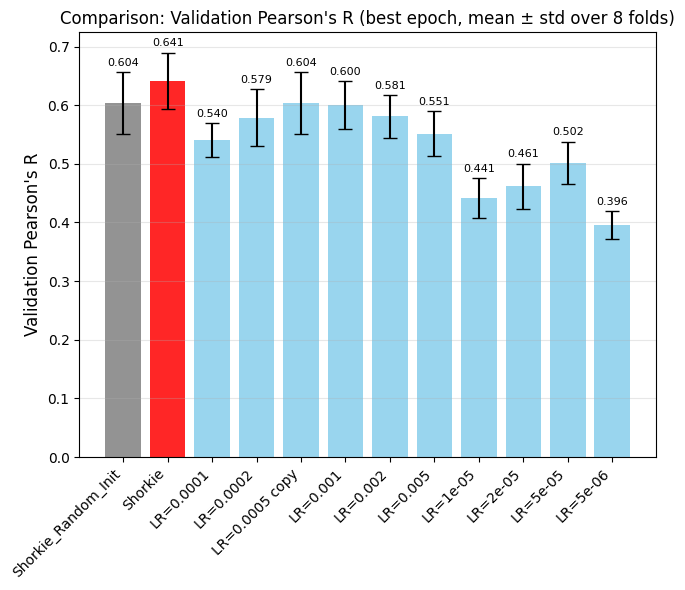

In [6]:
# ------------------------------------------------------------------
# Representative panel: Validation Pearson's R bar chart.
# Shorkie_Random_Init (scratch) and Shorkie (LM-finetuned) are pinned first.
# ------------------------------------------------------------------
def plot_bar(metric_results, metric_name, y_label=None):
    priority = ['Shorkie_Random_Init', 'Shorkie']
    keys = sorted(metric_results.keys())
    ordered = [p for p in priority if p in keys] + [k for k in keys if k not in priority]
    means = [metric_results[k]['mean'] for k in ordered]
    stds = [metric_results[k]['std'] for k in ordered]
    colors = ['gray' if k == 'Shorkie_Random_Init' else 'red' if k == 'Shorkie' else 'skyblue' for k in ordered]

    fig, ax = plt.subplots(figsize=(6.8, 6))
    x = np.arange(len(ordered))
    bars = ax.bar(x, means, yerr=stds, align='center', alpha=0.85, ecolor='black', capsize=5, color=colors)
    ax.set_ylabel(y_label or metric_name, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(ordered, rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Comparison: {metric_name} (best epoch, mean ± std over {num_folds} folds)', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    for b, s in zip(bars, stds):
        ax.annotate(f'{b.get_height():.3f}', xy=(b.get_x() + b.get_width() / 2, b.get_height() + s),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    return fig

plot_bar(stats['valid_r'], "Validation Pearson's R")
plt.show()

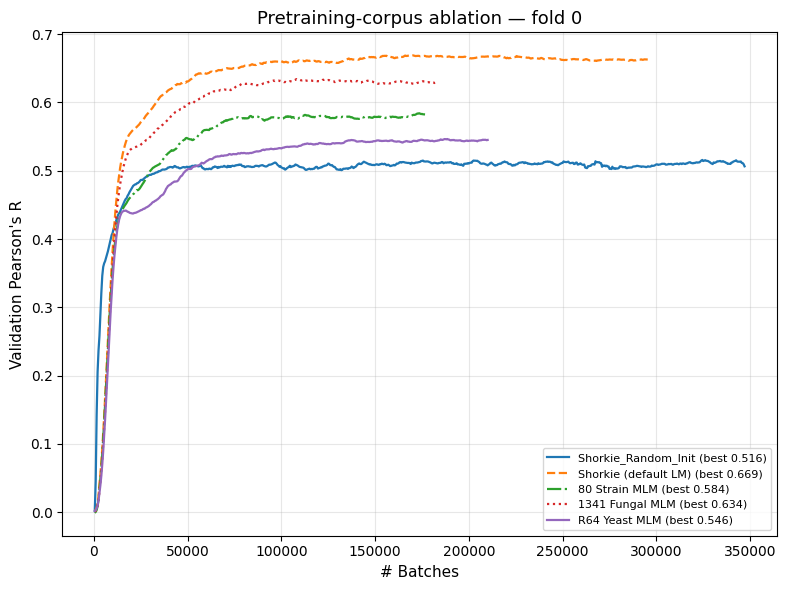

In [7]:
# ------------------------------------------------------------------
# Finetuning-corpus ablation: validation Pearson's R curves over training
# for one representative fold (fold 0). Compares no-pretraining (scratch) against
# LM pretraining on different corpora -- the core LM-impact comparison.
# ------------------------------------------------------------------
steps_per_epoch = 500
mlm_load = os.path.join(train_logs_root, f'self_supervised_{model_arch}_all_mlm_load')
corpus_groups = [
    ('Shorkie_Random_Init', os.path.join(train_logs_root, f'supervised_{model_arch}'), '#1f77b4', '-'),
    ('Shorkie (default LM)', os.path.join(train_logs_root, f'self_supervised_{model_arch}'), '#ff7f0e', '--'),
    ('80 Strain MLM', os.path.join(mlm_load, '80_strains_mlm'), '#2ca02c', '-.'),
    ('1341 Fungal MLM', os.path.join(mlm_load, '1341_fungal_mlm'), '#d62728', ':'),
    ('R64 Yeast MLM', os.path.join(mlm_load, 'yeast_mlm'), '#9467bd', '-'),
]

fold_i = 0
fig, ax = plt.subplots(figsize=(8, 6))
for name, exp_dir, color, ls in corpus_groups:
    cols = parse_all_metrics(os.path.join(exp_dir, 'train', f'f{fold_i}c0', 'train.out'))
    vals = cols['valid_r']
    if vals.size == 0:
        print(f'no log for {name}')
        continue
    smoothed = _moving_average(vals, window_size=11, trim_end=5)
    x = ((np.arange(vals.size) + 1) * steps_per_epoch)[:smoothed.size]
    ax.plot(x, smoothed, color=color, linestyle=ls, linewidth=1.6,
            label=f'{name} (best {smoothed.max():.3f})')
ax.set_xlabel('# Batches', fontsize=11)
ax.set_ylabel("Validation Pearson's R", fontsize=11)
ax.set_title(f'Pretraining-corpus ablation — fold {fold_i}', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

## Takeaway

Across folds, **Shorkie** (supervised head fine-tuned from the masked-DNA language model) attains a higher best-epoch validation Pearson's R than **Shorkie_Random_Init** (identical architecture trained from scratch), and converges with fewer batches. The learning-rate sweep shows the from-scratch baseline is not simply under-tuned, and the corpus ablation shows broader fungal pretraining corpora further help — isolating LM pretraining (not capacity or optimization) as the source of the gain. To regenerate the other metrics (loss, R²) or the per-fold architecture-search subplots, swap the metric key into `plot_bar(...)` / the curve loop, mirroring the source scripts.